## Imputation of time-series

Some of the code was found here for visualisation: https://cienciadedatos.net/documentos/py46-forecasting-time-series-missing-values

In [1]:
!nvidia-smi

Tue Apr 21 16:03:05 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.126.20             Driver Version: 580.126.20     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5090        On  |   00000000:01:00.0 Off |                  N/A |
|  0%   23C    P8              5W /  600W |       2MiB /  32607MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import sys

sys.path.append(".")
sys.path.append("./models")

from models.gp_wrapper import GPWrapper
from utils import *

import matplotlib.pyplot as plt

In [3]:
color = '\033[1m\033[38;5;208m' 
print(f"{color}Version numpy: {np.__version__}")
print(f"{color}Version pytorch: {torch.__version__}")

Version numpy: 2.4.4
Version pytorch: 2.8.0+cu128


### Load Data

In [4]:
from dataset_synthetic import get_dataloader
gpu = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_loader, valid_loader, test_loader = get_dataloader(device=gpu, batch_size=8)

Loaded SAGD training data with shape:  (100000, 25)
Training dataset len:  4128
Loaded SAGD training data with shape:  (100000, 25)
Valid dataset len:  15
Loaded SAGD training data with shape:  (100000, 25)
Test dataset len:  21


In [5]:
station_names = ["EST107PV", "EST3012", "EST5136", "EST5149", "EST5199", "EST6000", "OPE90011", "OPE90012", "OPE90013", "OPE90014", "OPE90015"]

parameter_names = ['CHL','CL','COD','CYA','DO','EC','HAP','NO3','PH','SAT','TEM','TUR', 'HTE']

# Load complementary info. Not useful rn, it's mostly polish for titles and dates...
# TODO I guess

def load_meta_data(path_list_dates = './data/ope_andra/dates_50.csv', path_sagd_parameters = './data/ope_andra/sagd_parameters_50_hte.csv'):
    dates_data = np.loadtxt(path_list_dates, dtype=str, delimiter=',')

    sagd_parameters_data = np.loadtxt(path_sagd_parameters, dtype=str, delimiter=',')


    return dates_data, sagd_parameters_data

dates_data, sagd_parameters_data = load_meta_data()

# best way to get the index at which the test data begins
test_index = test_loader.dataset.use_index[0]
test_dates = dates_data[test_index:]

In [6]:
data_dim = 75

## Model Definition and Training

In [7]:
from sklearn.gaussian_process.kernels import RBF, ExpSineSquared, WhiteKernel, Matern

gp_kernel = (
    Matern(length_scale=10.0, nu=1.5) *
    ExpSineSquared(length_scale=2.0, periodicity=6.0)
    + Matern(length_scale=3.0, nu=1.5)
    + WhiteKernel(noise_level=0.1)
)

model = GPWrapper(gp_kernel)

In [8]:
import numpy as np
import torch
from sklearn.gaussian_process import GaussianProcessRegressor

def run_gp_and_compute_quantiles(
        X, 
        observations, 
        mask, 
        kernel,
        nsamples=100,
        qlist=[0.05,0.25,0.5,0.75,0.95],
):
    """
    Returns:
        quantiles_gp: list of quantile arrays like CSDI
            quantiles_gp[q].shape = (B, L, K)
        gp_samples: full sample tensor like CSDI (B, nsample, L, K)
    """

    B, L, K = observations.shape  # Batch, Length, Features
    mask_np = mask.cpu().numpy()
    obs_np  = observations.cpu().numpy()

    # Output containers
    gp_samples = np.zeros((B, nsamples, L, K))
    
    # Loop over batch + features
    for b in range(B):
        for k in range(K):

            # Training indices = where mask == 1
            train_idx = np.where(mask_np[b, :, k] == 1)[0]

            if len(train_idx) == 0:
                # No data → flat zero predictions
                gp_samples[b, :, :, k] = 0.0
                continue

            X_train = X[train_idx]
            y_train = obs_np[b, train_idx, k]

            gp = GaussianProcessRegressor(
                kernel=kernel,
                n_restarts_optimizer=5,
                normalize_y=True,
            )

            # Fit
            gp.fit(X_train.reshape(-1, 1), y_train)

            mean_pred, std_pred = gp.predict(X.reshape(-1, 1), return_std=True)

            samples = np.random.normal(
                loc=mean_pred[None, :],
                scale=std_pred[None, :],
                size=(nsamples, L)
            )

            # Store
            gp_samples[b, :, :, k] = samples

    # Convert to torch for quantiles
    gp_samples_torch = torch.tensor(gp_samples)   # (B, nsample, L, K)
    mask_torch = torch.tensor(mask_np).float()
    target_torch = torch.tensor(obs_np).float()

    # ----------- Compute quantiles like CSDI ----------- #
    quantiles_gp = []
    for q in qlist:
        q_val = torch.quantile(gp_samples_torch, q, dim=1)  # (B, L, K)
        # replace GP outputs with ground truth for given points
        q_val = q_val * (1 - mask_torch) + target_torch * mask_torch
        quantiles_gp.append(q_val)

    return quantiles_gp, gp_samples_torch


In [9]:
import numpy as np
from collections import defaultdict

horizons = [6, 12, 18]
n_trials = 5

results = {h: defaultdict(list) for h in horizons}

# Run trials
for trial in range(n_trials):
    print(f"Trial {trial+1}/{n_trials}")
    
    for h in horizons:
        out = evaluate_forecasting(
            model,
            test_loader,
            prediction_horizon=h,
            nsample=100,
        )
        
        for key, value in out.items():
            results[h][key].append(value)

# Compute mean & std
print("\n=== Forecasting Results ===")
for h in horizons:
    print(f"\nHorizon: {h}")
    
    for metric in results[h]:
        values = np.array(results[h][metric])
        mean = values.mean()
        std = values.std()
        
        print(f"{metric}: {mean:.4f} ± {std:.4f}")

Trial 1/5


100%|██████████| 3/3 [07:16<00:00, 145.64s/it, rmse_total=0.082, mae_total=0.0484, smape_total=16.8, batch_no=3] 


Trial 2/5


100%|██████████| 3/3 [06:48<00:00, 136.10s/it, rmse_total=0.0822, mae_total=0.0485, smape_total=16.9, batch_no=3]


Trial 3/5


...

Trial 4/5


100%|██████████| 3/3 [07:02<00:00, 140.81s/it, rmse_total=0.0826, mae_total=0.0483, smape_total=16.8, batch_no=3]


Trial 5/5


100%|██████████| 3/3 [06:25<00:00, 128.43s/it, rmse_total=0.0825, mae_total=0.0485, smape_total=16.8, batch_no=3]



=== Forecasting Results ===

Horizon: 6
rmse: 0.0529 ± 0.0007
mae: 0.0284 ± 0.0002
smape: 9.8296 ± 0.0487
CRPS: 0.0699 ± 0.0005
CRPS_sum: 0.0055 ± 0.0000

Horizon: 12
rmse: 0.0770 ± 0.0004
mae: 0.0442 ± 0.0002
smape: 14.5196 ± 0.0939
CRPS: 0.1047 ± 0.0004
CRPS_sum: 0.0158 ± 0.0001

Horizon: 18
rmse: 0.0823 ± 0.0002
mae: 0.0484 ± 0.0001
smape: 16.8145 ± 0.0592
CRPS: 0.1159 ± 0.0003
CRPS_sum: 0.0255 ± 0.0001


In [10]:
import numpy as np
from collections import defaultdict

ratios = [0.25, 0.50, 0.75, 0.90]
n_trials = 5

results = {r: defaultdict(list) for r in ratios}

# Run trials
for trial in range(n_trials):
    print(f"Trial {trial+1}/{n_trials}")
    
    for seed, r in enumerate(ratios):
        out = evaluate_imputation(
            model,
            test_loader,
            ratio_missing=r,
            nsample=100,
            seed=seed,
        )
        
        for key, value in out.items():
            results[r][key].append(value)

# Compute mean & std
print("\n=== Imputation Results ===")
for r in ratios:
    print(f"\nMissing Ratio: {r}")
    
    for metric in results[r]:
        values = np.array(results[r][metric])
        mean = values.mean()
        std = values.std()
        
        print(f"{metric}: {mean:.4f} ± {std:.4f}")

Trial 1/5


100%|██████████| 3/3 [01:46<00:00, 35.47s/it, rmse_total=0.0689, mae_total=0.04, smape_total=14.3, batch_no=3]  


Trial 2/5


100%|██████████| 3/3 [01:46<00:00, 35.56s/it, rmse_total=0.0686, mae_total=0.0398, smape_total=14.3, batch_no=3]


Trial 3/5


...

Trial 4/5


100%|██████████| 3/3 [01:51<00:00, 37.08s/it, rmse_total=0.0685, mae_total=0.04, smape_total=14.4, batch_no=3]  


Trial 5/5


100%|██████████| 3/3 [01:45<00:00, 35.26s/it, rmse_total=0.0689, mae_total=0.0402, smape_total=14.3, batch_no=3]



=== Imputation Results ===

Missing Ratio: 0.25
rmse: 0.0272 ± 0.0001
mae: 0.0151 ± 0.0000
smape: 5.4961 ± 0.0113
CRPS: 0.0354 ± 0.0001
CRPS_sum: 0.0031 ± 0.0000

Missing Ratio: 0.5
rmse: 0.0323 ± 0.0001
mae: 0.0175 ± 0.0000
smape: 6.1521 ± 0.0150
CRPS: 0.0411 ± 0.0001
CRPS_sum: 0.0058 ± 0.0000

Missing Ratio: 0.75
rmse: 0.0438 ± 0.0002
mae: 0.0239 ± 0.0000
smape: 8.2759 ± 0.0184
CRPS: 0.0567 ± 0.0001
CRPS_sum: 0.0142 ± 0.0001

Missing Ratio: 0.9
rmse: 0.0687 ± 0.0002
mae: 0.0400 ± 0.0001
smape: 14.3499 ± 0.0307
CRPS: 0.0959 ± 0.0003
CRPS_sum: 0.0429 ± 0.0002


In [11]:
rng = np.random.RandomState(1)

# generate one batch
for batch in test_loader:
    observed_mask = batch['observed_mask']
    # set later half to 0
    #print(observed_mask_forecast.shape)
    real_data = batch['observed_data']

    observed_mask_forecast = observed_mask.clone()
    observed_mask_forecast[:, 18:] = 0

    observed_data = batch['observed_data']
    observed_data = observed_data * observed_mask_forecast

In [12]:
X = np.arange(real_data.shape[0]).reshape(-1, 1)

all_target_np = real_data
all_evalpoint_np = observed_mask.cpu() - observed_mask_forecast.cpu() #observed_mask_forecast.cpu() # with later points se tto 0
all_observed_np = observed_mask.cpu() # all points
all_given_np = observed_mask_forecast.cpu() # observations

K = real_data.shape[-1] #feature
L = real_data.shape[-2] #time length

In [13]:
quantiles_gp, gp_samples = run_gp_and_compute_quantiles(
    X=np.arange(L),
    observations=all_target_np,
    mask=all_given_np,
    kernel=gp_kernel,
    nsamples=100
)


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning:

In [14]:
quantiles_gp[0].shape

torch.Size([5, 72, 25])

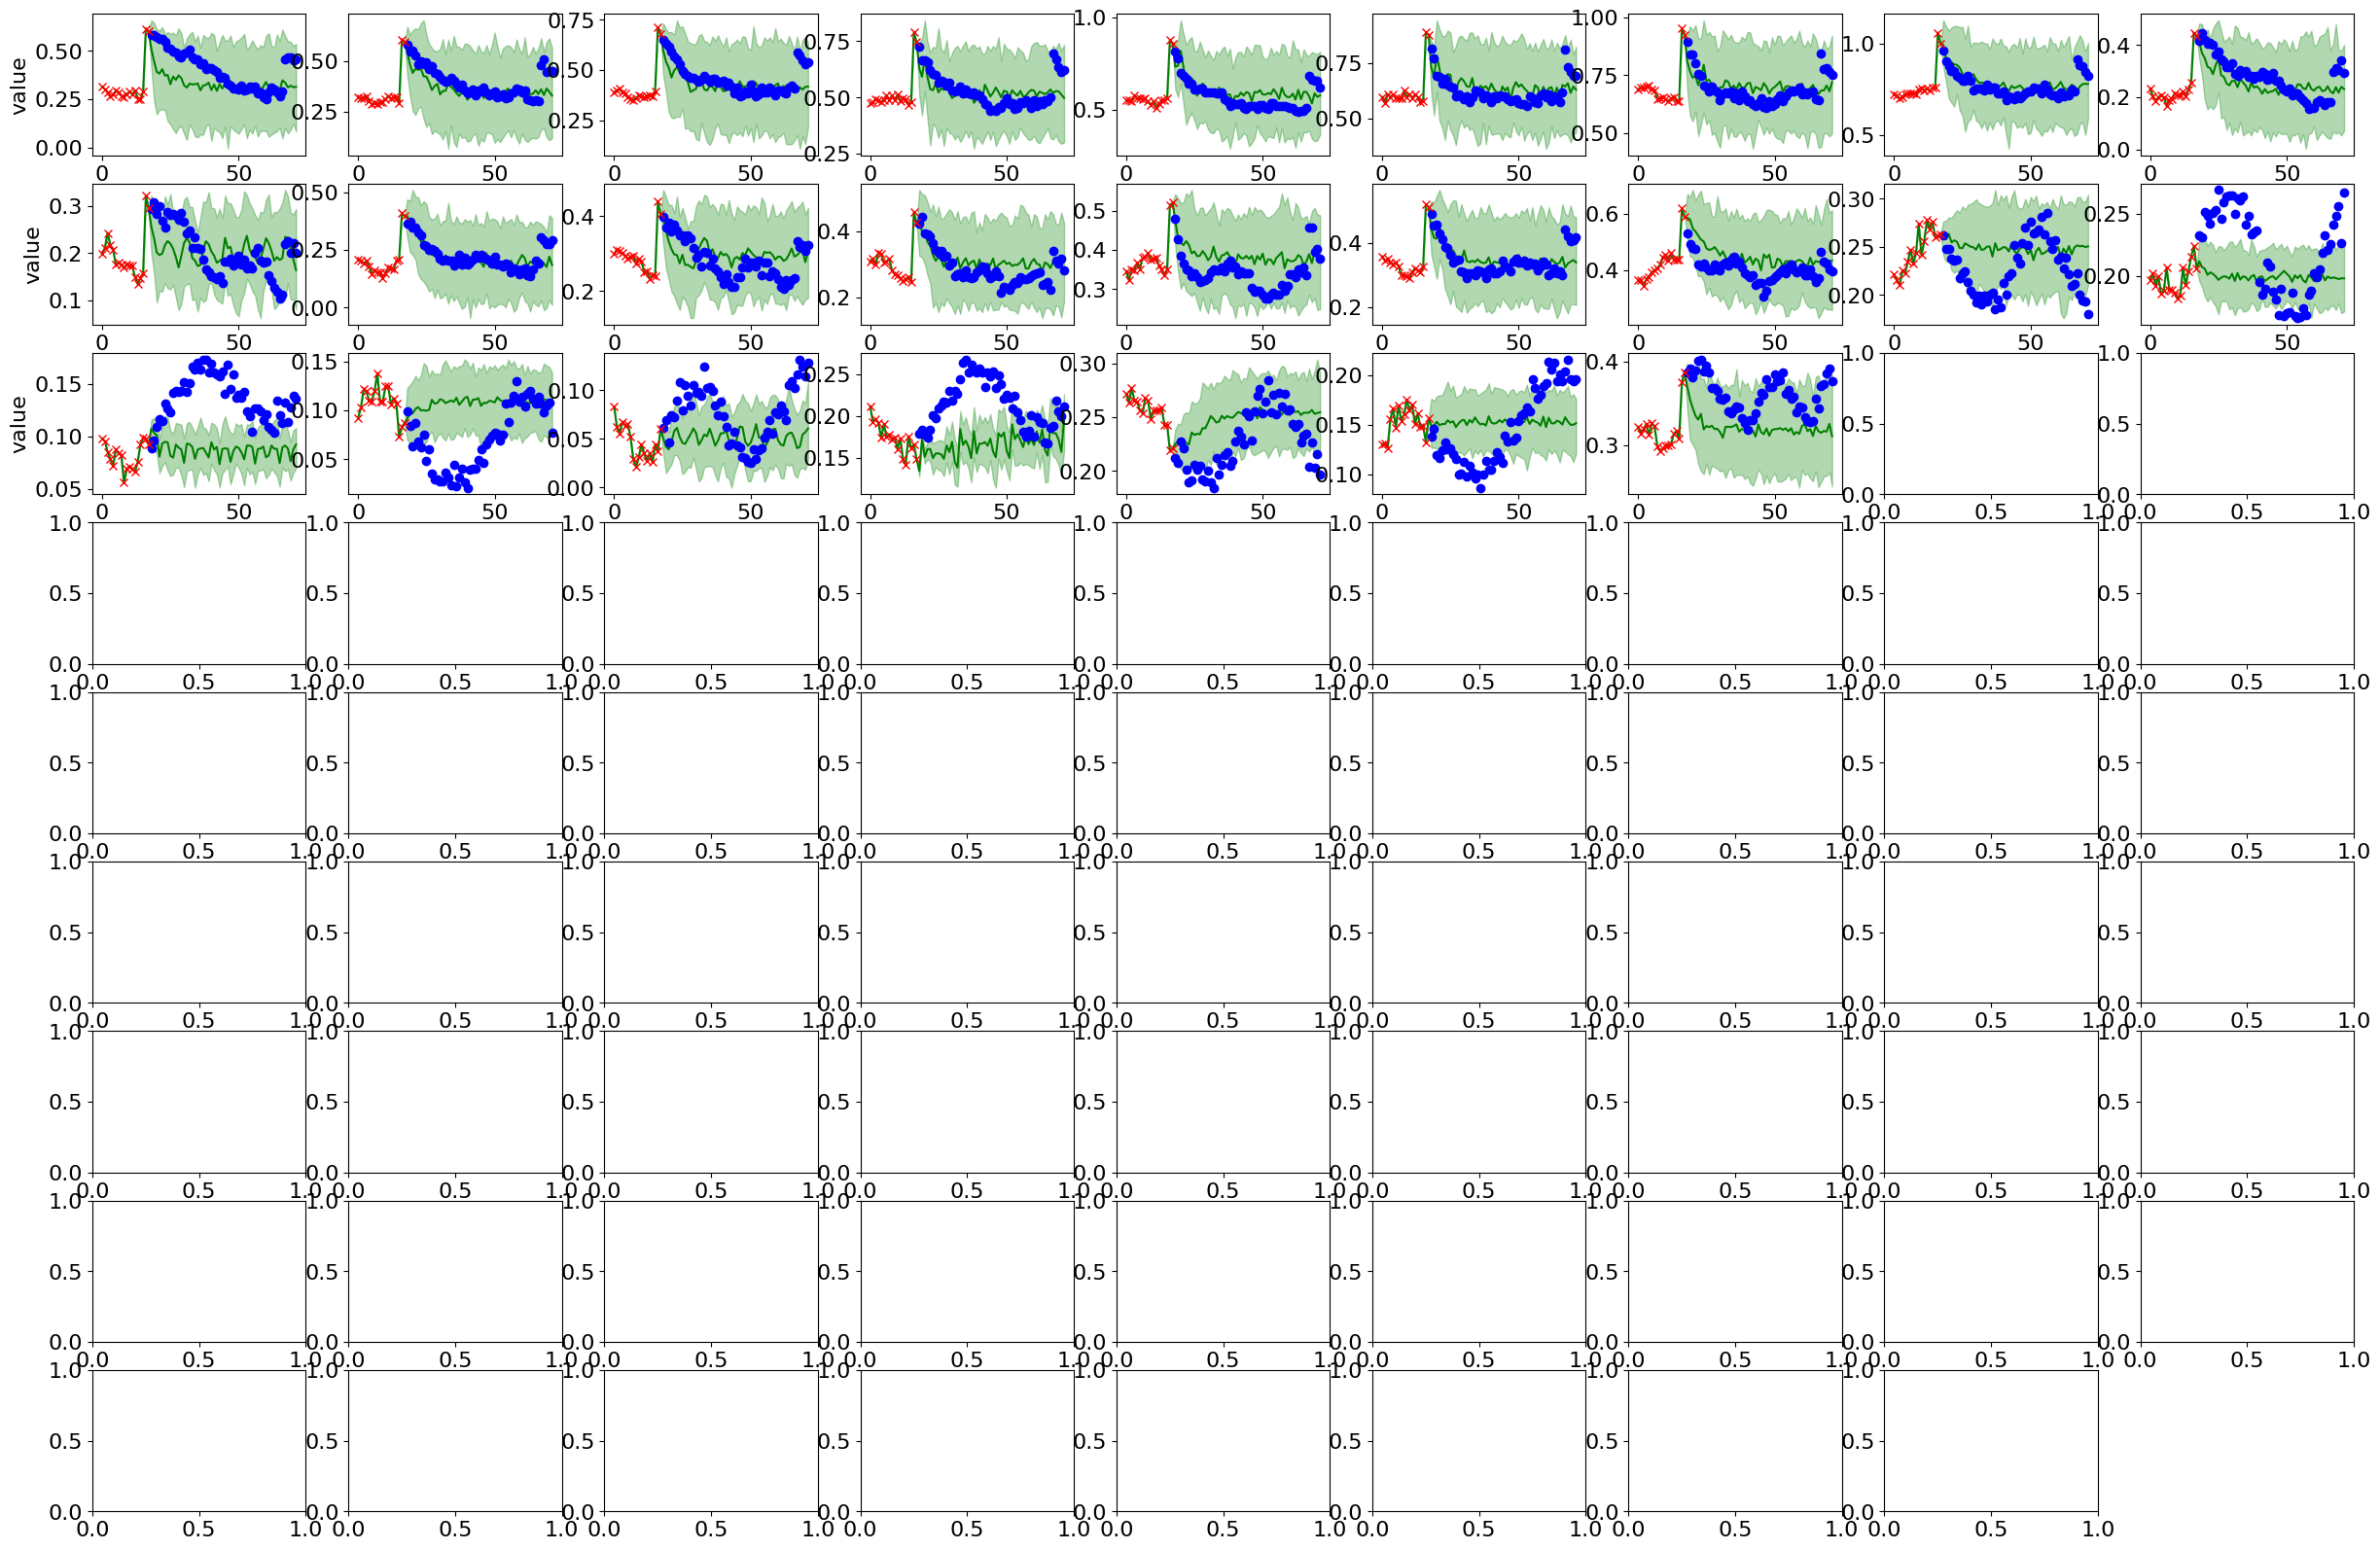

In [15]:
###airquality###
dataind = 0 #change to visualize a different sample

plt.rcParams["font.size"] = 16
fig, axes = plt.subplots(nrows=9, ncols=9,figsize=(30.0, 20.0))
fig.delaxes(axes[-1][-1])

for k in range(K):
    df = pd.DataFrame({"x":np.arange(0,L), "val":all_target_np[dataind,:,k], "y":all_evalpoint_np[dataind,:,k]})
    df = df[df.y != 0]
    df2 = pd.DataFrame({"x":np.arange(0,L), "val":all_target_np[dataind,:,k], "y":all_given_np[dataind,:,k]})
    df2 = df2[df2.y != 0]
    row = k // 9
    col = k % 9
    axes[row][col].plot(range(0,L), quantiles_gp[2][dataind,:,k], color = 'g',linestyle='solid',label='CSDI')
    axes[row][col].fill_between(range(0,L), quantiles_gp[0][dataind,:,k],quantiles_gp[4][dataind,:,k],
                    color='g', alpha=0.3)
    axes[row][col].plot(df.x,df.val, color = 'b',marker = 'o', linestyle='None')
    axes[row][col].plot(df2.x,df2.val, color = 'r',marker = 'x', linestyle='None')
    if col == 0:
        plt.setp(axes[row, 0], ylabel='value')
    if row == -1:
        plt.setp(axes[-1, col], xlabel='time')


In [16]:
train_loader, valid_loader, test_loader = get_dataloader(device=gpu, batch_size=8, long_data=True)

Loaded SAGD training data with shape:  (100000, 25)
Training dataset len:  4128
Loaded SAGD training data with shape:  (100000, 25)
Valid dataset len:  15
Loaded SAGD training data with shape:  (100000, 25)
Test dataset len:  1


In [18]:
import time

rng = np.random.RandomState(0)

# generate one batch
for batch in test_loader:
    observed_mask = batch['observed_mask']
    # set later half to 0
    #print(observed_mask_forecast.shape)
    real_data = batch['observed_data']

    observed_mask_forecast = observed_mask.clone()
    observed_mask_forecast[:, 90:] = 0

    observed_data = batch['observed_data']
    observed_data = observed_data * observed_mask_forecast

    #observed_mask_forecast = observed_mask_forecast.to(model.device).float()
    #observed_data = observed_data.to(model.device).float()
    with torch.no_grad():
        start_time = time.time()  # Start timer
        generated = model.impute(observed_data, observed_mask_forecast, n_samples=100, timestamps=batch['timepoints'])
        end_time = time.time()  # End timer
        break

generated_test = generated.permute([0, 1, 3, 2]).cpu()
X = np.arange(generated_test.shape[0]).reshape(-1, 1)

all_target_np = real_data
all_evalpoint_np = observed_mask.cpu() - observed_mask_forecast.cpu() #observed_mask_forecast.cpu() # with later points se tto 0
all_observed_np = observed_mask.cpu() # all points
all_given_np = observed_mask_forecast.cpu() # observations

K = generated_test.shape[-1] #feature
L = generated_test.shape[-2] #time length

In [19]:
def get_quantile(samples,q,dim=1):
    return torch.quantile(samples,q,axis=dim)

qlist =[0.05,0.25,0.5,0.75,0.95]
quantiles_imp= []
for q in qlist:
    quantiles_imp.append(get_quantile(generated_test, q, dim=1)*(1-all_given_np) + all_target_np * all_given_np)

print(quantiles_imp[0].shape)

torch.Size([1, 552, 25])


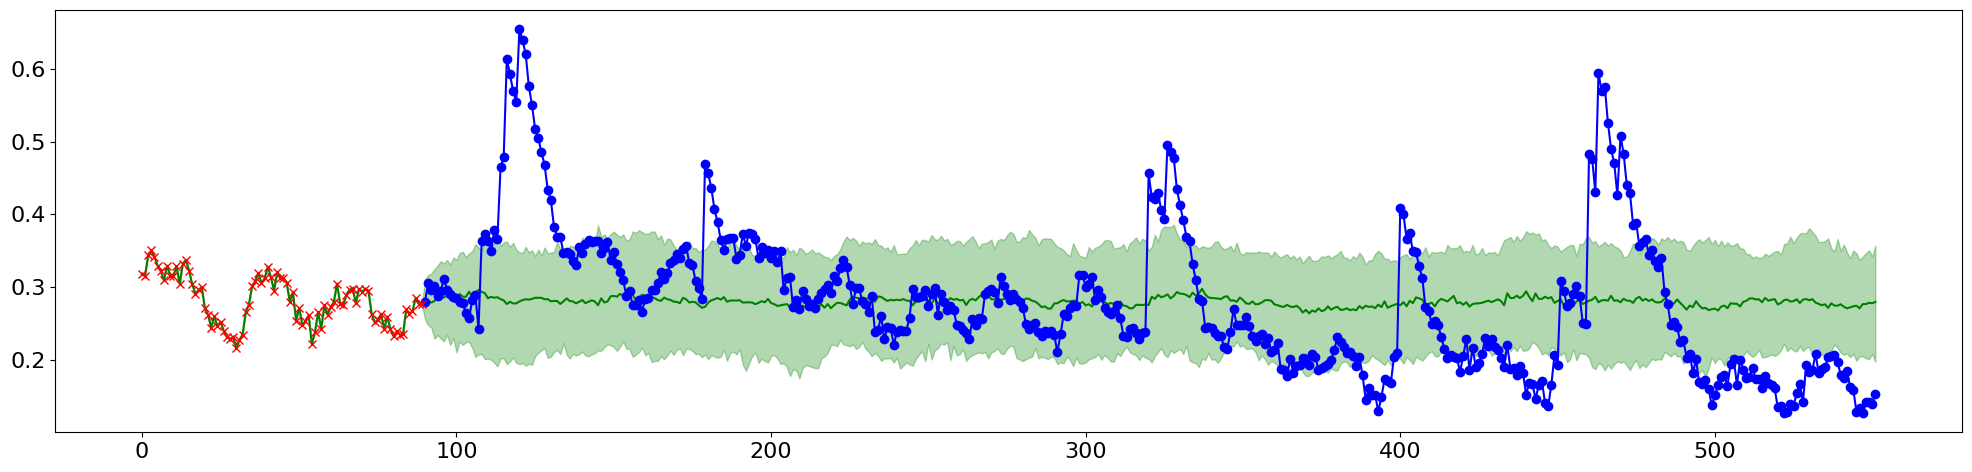

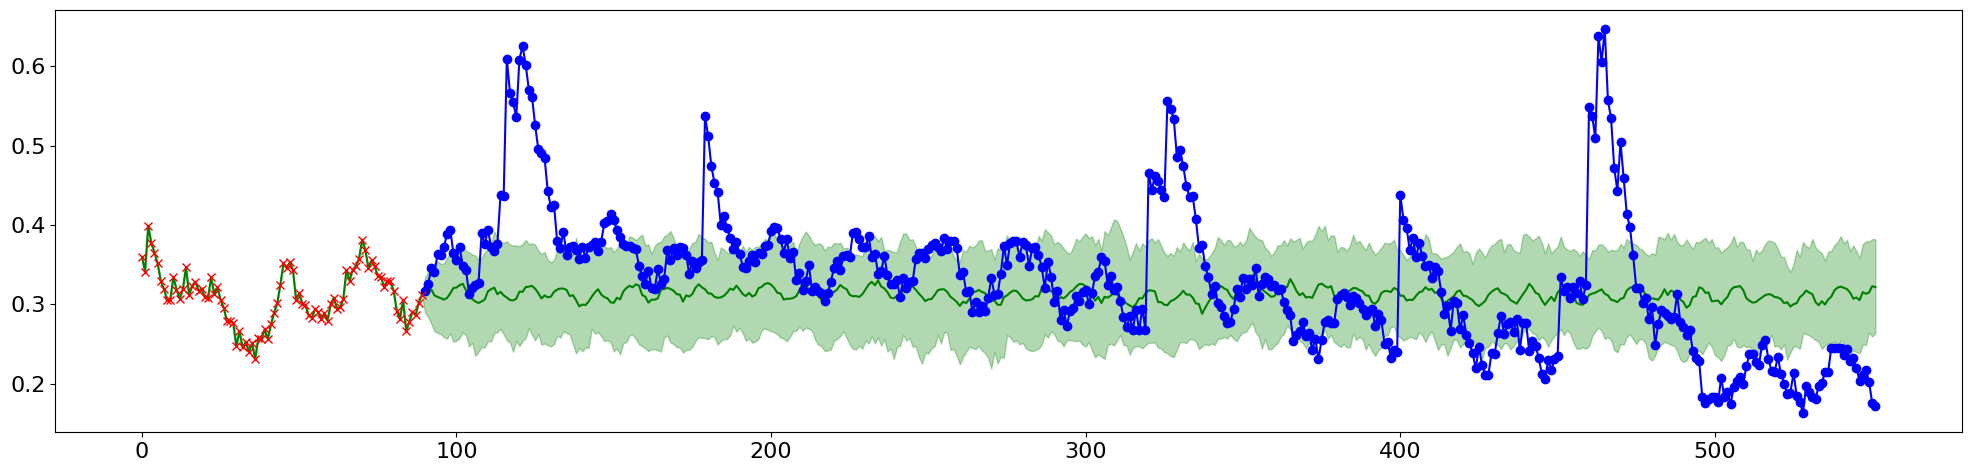

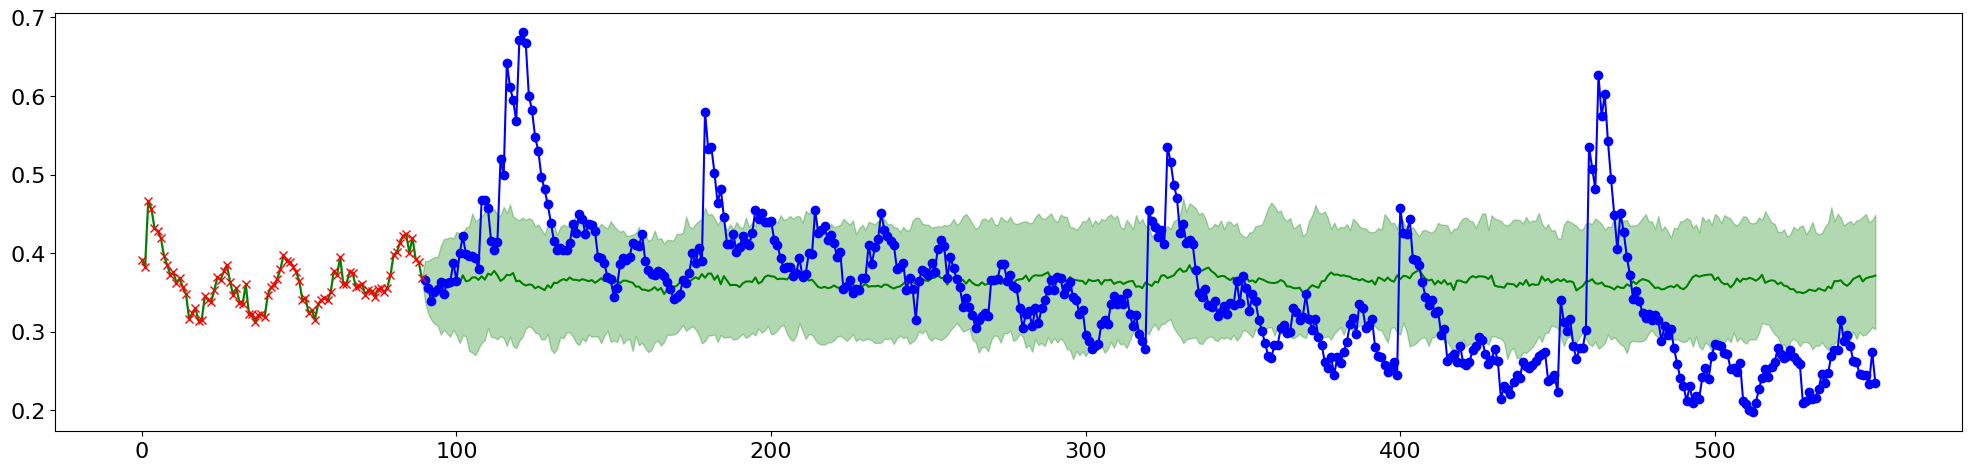

In [20]:
import matplotlib.dates as mdates

###airquality###
dataind = 0 #change to visualize a different sample

plt.rcParams["font.size"] = 16

station = "OPE90012"
indices = list(range(10, 13))
for k in indices:

    fig, ax = plt.subplots(figsize=(20, 5))
    df = pd.DataFrame({"x":np.arange(0,L), "val":all_target_np[dataind,:,k], "y":all_evalpoint_np[dataind,:,k]})
    df = df[df.y != 0]
    df2 = pd.DataFrame({"x":np.arange(0,L), "val":all_target_np[dataind,:,k], "y":all_given_np[dataind,:,k]})
    df2 = df2[df2.y != 0]
    #row = k // 9
    #col = k % 9
    plt.plot(range(0,L), quantiles_imp[2][dataind,:,k], color = 'g',linestyle='solid',label='CSDI')
    plt.fill_between(range(0,L), quantiles_imp[0][dataind,:,k],quantiles_imp[4][dataind,:,k],
                    color='g', alpha=0.3)
    plt.plot(df.x,df.val, color = 'b',)
    #plt.plot(df2.x,df2.val, color = 'r',)
    plt.plot(df.x,df.val, color = 'b',marker = 'o', linestyle='None')
    plt.plot(df2.x,df2.val, color = 'r',marker = 'x', linestyle='None')
    # replace x axis ticks with dates, only showing days, formatin dates not hours


    plt.tight_layout()
    plt.show()
    plt.show()


In [21]:
seasonal_vars = list(range(12, 24))

real_data.shape, generated_test.shape


#> (torch.Size([1, 552, 25]), torch.Size([1, 100, 552, 25]))

(torch.Size([1, 552, 25]), torch.Size([1, 100, 552, 25]))

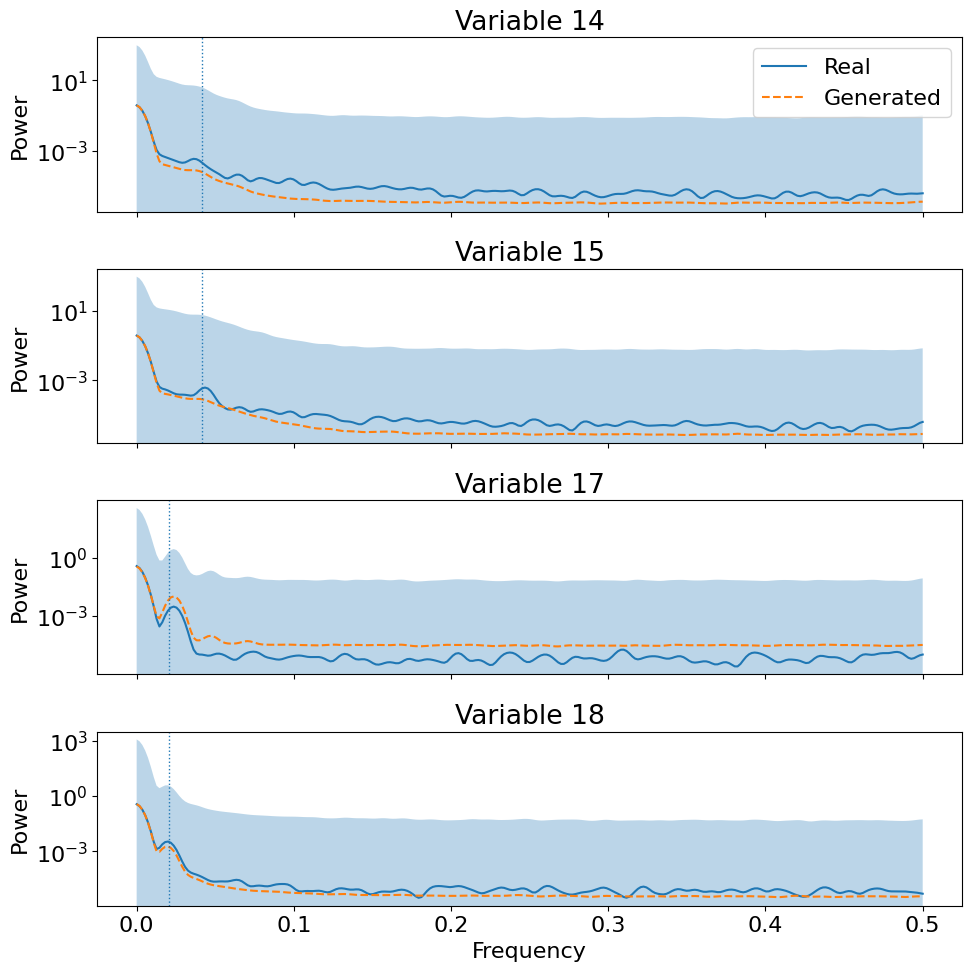

In [22]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage

# ----------------------------
# CONFIG
# ----------------------------
seasonal_vars = [14, 15, 17, 18] #list(range(8, 24))
SMOOTH_SIGMA = 2        # set 0 to disable smoothing
NORMALIZE = True        # normalize spectra
LOG_SCALE = True        # log scale for y-axis

# ----------------------------
# DATA PREP
# ----------------------------
# real_data: (1, 552, 25)
# generated_test: (1, 100, 552, 25)

real = real_data[0, :, seasonal_vars]           # (552, 12)
gen  = generated_test[0, :, :, seasonal_vars]  # (100, 552, 12)

T = real.shape[0]

# ----------------------------
# PSD FUNCTION
# ----------------------------
def compute_psd(x, dim):
    fft_vals = torch.fft.rfft(x, dim=dim)
    psd = torch.abs(fft_vals) ** 2
    return psd

# ----------------------------
# COMPUTE PSD
# ----------------------------
real_psd = compute_psd(real, dim=0)     # (freq, vars)
gen_psd  = compute_psd(gen, dim=1)      # (samples, freq, vars)

# Mean + std over simulations
gen_psd_mean = gen_psd.mean(dim=0)
gen_psd_std  = gen_psd.std(dim=0)

# ----------------------------
# NORMALIZATION (optional)
# ----------------------------
if NORMALIZE:
    real_psd = real_psd / real_psd.sum(dim=0, keepdim=True)
    gen_psd_mean = gen_psd_mean / gen_psd_mean.sum(dim=0, keepdim=True)
    gen_psd_std = gen_psd_std / gen_psd_mean.sum(dim=0, keepdim=True)

# ----------------------------
# TO NUMPY
# ----------------------------
real_psd_np = real_psd.cpu().numpy()
gen_psd_mean_np = gen_psd_mean.cpu().numpy()
gen_psd_std_np = gen_psd_std.cpu().numpy()

# ----------------------------
# SMOOTHING (optional)
# ----------------------------
if SMOOTH_SIGMA > 0:
    real_psd_np = scipy.ndimage.gaussian_filter1d(real_psd_np, sigma=SMOOTH_SIGMA, axis=0)
    gen_psd_mean_np = scipy.ndimage.gaussian_filter1d(gen_psd_mean_np, sigma=SMOOTH_SIGMA, axis=0)
    gen_psd_std_np = scipy.ndimage.gaussian_filter1d(gen_psd_std_np, sigma=SMOOTH_SIGMA, axis=0)

# ----------------------------
# FREQUENCY AXIS
# ----------------------------
freqs = np.fft.rfftfreq(T)

# ----------------------------
# PLOTTING
# ----------------------------
n_vars = len(seasonal_vars)
fig, axes = plt.subplots(n_vars, 1, figsize=(10, 2.5 * n_vars), sharex=True)

if n_vars == 1:
    axes = [axes]

for i in range(n_vars):
    ax = axes[i]

    # Real
    ax.plot(freqs, real_psd_np[:, i], label="Real")
    
        
    # Generated mean
    ax.plot(freqs, gen_psd_mean_np[:, i], linestyle="--", label="Generated")

    # Confidence band
    ax.fill_between(
        freqs,
        gen_psd_mean_np[:, i] - gen_psd_std_np[:, i],
        gen_psd_mean_np[:, i] + gen_psd_std_np[:, i],
        alpha=0.3
    )


    ax.set_title(f"Variable {seasonal_vars[i]}")
    ax.set_ylabel("Power")

    if LOG_SCALE:
        ax.set_yscale("log")
    if i == 0:
        ax.legend(loc="upper right")

half = len(axes) // 2  # 6

for i, ax in enumerate(axes):
    if i < half:
        f = 1 / 24
    else:
        f = 1 / 48

    ax.axvline(f, linestyle=":", linewidth=1)

axes[-1].set_xlabel("Frequency")
plt.tight_layout()
plt.show()

In [24]:
import numpy as np
from scipy.stats import wasserstein_distance

EPS = 1e-8  # numerical stability

seasonal_vars = list(range(8, 24))


# Remove DC component (VERY important)
real_psd_np_cut = real_psd_np[1:]
gen_psd_mean_np_cut = gen_psd_mean_np[1:]

n_vars = real_psd_np_cut.shape[1]

lsd_list = []
wass_list = []
rel_err_list = []

for i in range(n_vars):
    r = real_psd_np_cut[:, i]
    g = gen_psd_mean_np_cut[:, i]

    # Normalize to distributions (for Wasserstein)
    r_norm = r / (r.sum() + EPS)
    g_norm = g / (g.sum() + EPS)

    # ------------------
    # 1. Log Spectral Distance
    # ------------------
    lsd = np.sqrt(np.mean((np.log(r + EPS) - np.log(g + EPS))**2))
    lsd_list.append(lsd)

    # ------------------
    # 2. Wasserstein distance
    # ------------------
    wass = wasserstein_distance(
        np.arange(len(r_norm)),
        np.arange(len(g_norm)),
        r_norm,
        g_norm
    )
    wass_list.append(wass)

    # ------------------
    # 3. Relative error
    # ------------------
    rel_err = np.mean(np.abs(r - g) / (r + EPS))
    rel_err_list.append(rel_err)

# ----------------------------
# Aggregate results
# ----------------------------
print("=== Spectral Metrics ===")
print(f"LSD (mean):        {np.mean(lsd_list):.4f}")
print(f"Wasserstein (mean):{np.mean(wass_list):.4f}")
print(f"Rel Error (mean):  {np.mean(rel_err_list):.4f}")

# Per-variable breakdown
print("\nPer-variable LSD:")
for i, val in enumerate(lsd_list):
    print(f"Var {seasonal_vars[i]}: {val:.4f}")

=== Spectral Metrics ===
LSD (mean):        1.0279
Wasserstein (mean):0.6031
Rel Error (mean):  1.0698

Per-variable LSD:
Var 8: 0.8611
Var 9: 1.2698
Var 10: 1.1594
Var 11: 1.0330
Var 12: 1.1705
Var 13: 1.0307
Var 14: 1.3566
Var 15: 1.2554
Var 16: 0.9174
Var 17: 1.5773
Var 18: 0.6924
Var 19: 0.6735
Var 20: 0.6039
Var 21: 0.6052
Var 22: 1.4245
Var 23: 0.8152
